In [1]:
import ants

# Import Template and Raw Images

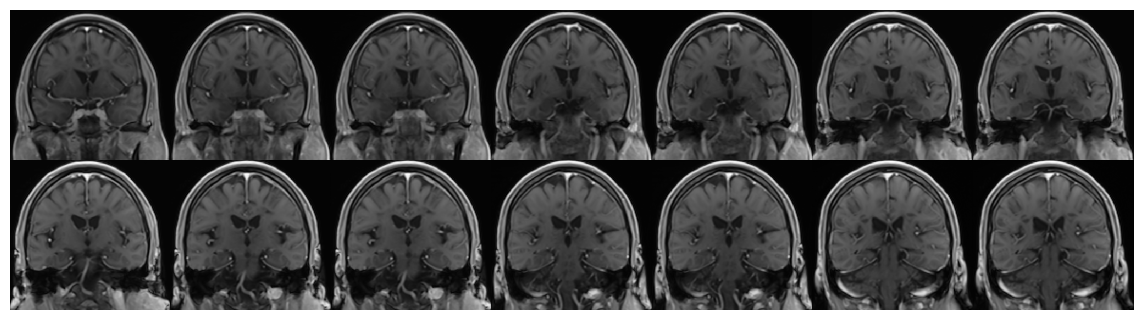

In [10]:
toreg_baselineDCE = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/baseline/meant1_vibe_cor_dynamic_waterext_12.nii")
ants.plot(toreg_baselineDCE, nslices=14, ncol=7, axis=1, crop=True)

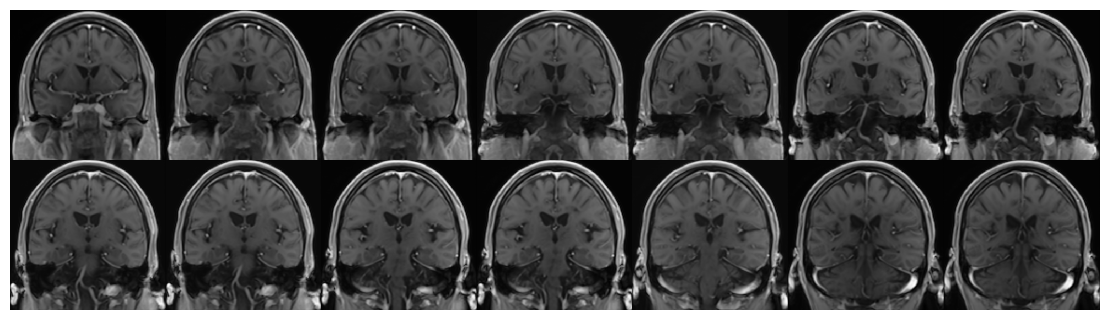

In [11]:
toreg_6mDCE = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/followup/meant1_vibe_cor_dynamic_waterext_11.nii")
ants.plot(toreg_6mDCE, nslices=14, ncol=7, axis=1, crop=True)

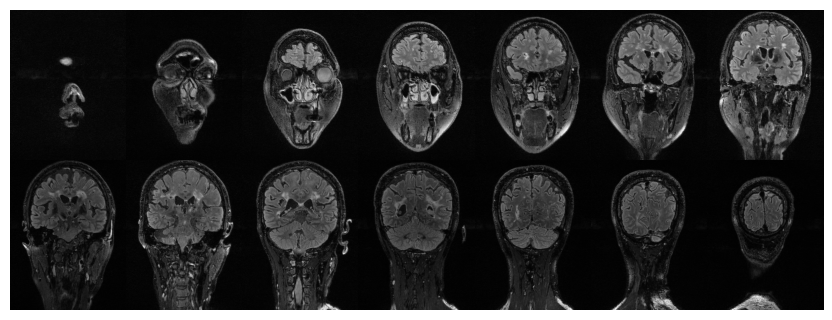

In [12]:
toreg_baselineFLAIR = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/sub-001/ses-baseline/anat/sub-001_ses-baseline_FLAIR.nii.gz")
ants.plot(toreg_baselineFLAIR, nslices=14, ncol=7, axis=1, crop=True)

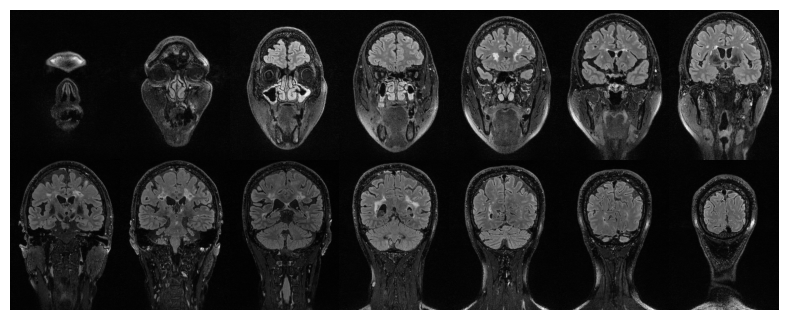

In [13]:
toreg_6mFLAIR = ants.image_read("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/sub-001/ses-6m/anat/sub-001_ses-6m_FLAIR.nii.gz")
ants.plot(toreg_6mFLAIR, nslices=14, ncol=7, axis=1, crop=True)

# ANTs Registration of FLAIR to DCE

In [15]:
trans_baseline = ants.registration(
    fixed=toreg_baselineDCE,
    moving=toreg_baselineFLAIR, 
    type_of_transform='SyN',
    verbose=True
)
trans_6m = ants.registration(
    fixed=toreg_6mDCE,
    moving=toreg_6mFLAIR, 
    type_of_transform='SyN',
    verbose=True
)

antsRegistration -d 3 -r [0000025028B7D788,00000250215C0888,1] -m mattes[0000025028B7D788,00000250215C0888,1,32,regular,0.2] -t Affine[0.25] -c 2100x1200x1200x0 -s 3x2x1x0 -f 4x2x2x1 -x [NA,NA] -m mattes[0000025028B7D788,00000250215C0888,1,32] -t SyN[0.200000,3.000000,0.000000] -c [40x20x0,1e-7,8] -s 2x1x0 -f 4x2x1 -u 1 -z 1 -o [C:\Users\Axis\AppData\Local\Temp\tmppeb3y21a,0000025028B7ECA8,0000025028B7D428] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1
antsRegistration -d 3 -r [00000250215C0888,00000250261F74C8,1] -m mattes[00000250215C0888,00000250261F74C8,1,32,regular,0.2] -t Affine[0.25] -c 2100x1200x1200x0 -s 3x2x1x0 -f 4x2x2x1 -x [NA,NA] -m mattes[00000250215C0888,00000250261F74C8,1,32] -t SyN[0.200000,3.000000,0.000000] -c [40x20x0,1e-7,8] -s 2x1x0 -f 4x2x1 -u 1 -z 1 -o [C:\Users\Axis\AppData\Local\Temp\tmp212wjton,0000025028B7D948,0000025028B7ECA8] -x [NA,NA] --float 1 --write-composite-transform 0 -v 1


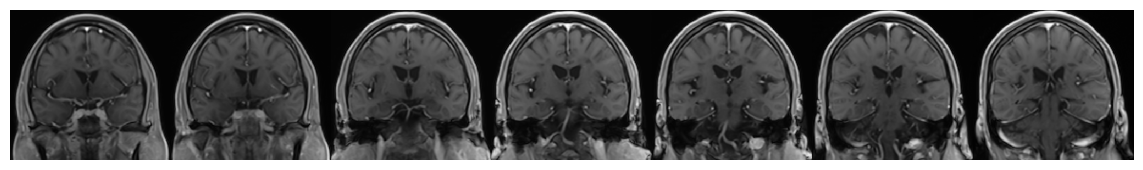

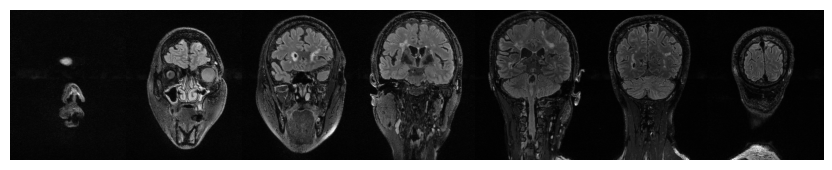

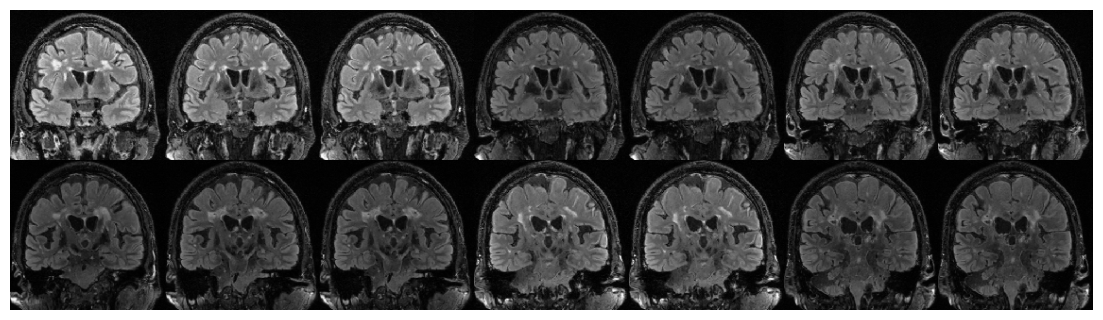

In [16]:
reged_baselineFLAIR = trans_baseline['warpedmovout']

ants.plot(toreg_baselineDCE, nslices=7, ncol=7, axis=1, crop=True)
ants.plot(toreg_baselineFLAIR, nslices=7, ncol=7, axis=1, crop=True)
ants.plot(reged_baselineFLAIR, nslices=14, ncol=7, axis=1, crop=True)

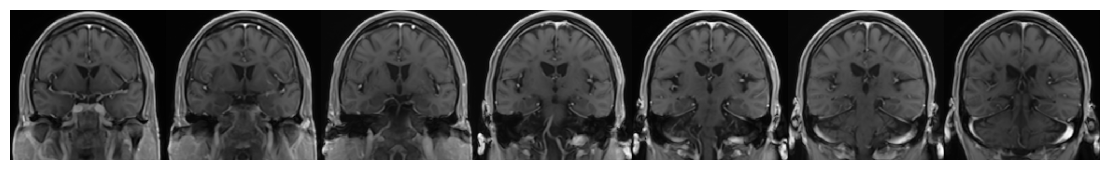

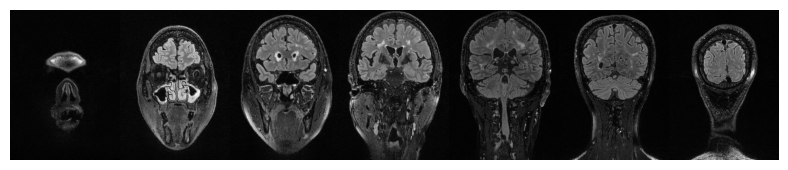

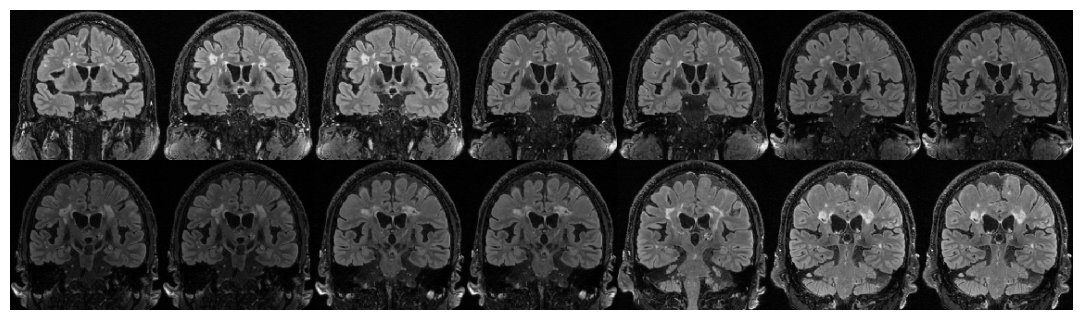

In [19]:
reged_6mFLAIR = trans_6m['warpedmovout']

ants.plot(toreg_6mDCE, nslices=7, ncol=7, axis=1, crop=True)
ants.plot(toreg_6mFLAIR, nslices=7, ncol=7, axis=1, crop=True)
ants.plot(reged_6mFLAIR, nslices=14, ncol=7, axis=1, crop=True)

# Export

In [20]:
reged_baselineFLAIR.to_file("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/derivatives/ANTs/reged_baselineFLAIR_DCE.nii.gz")
reged_6mFLAIR.to_file("Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/derivatives/ANTs/reged_6mFLAIR_DCE.nii.gz")